In [1]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
url = "http://books.toscrape.com/"
response = requests.get(url) 
soup = BeautifulSoup(response.text, "html.parser")

In [3]:
 books = soup.find_all("article", class_ ="product_pod")

In [4]:
 titles = []
 prices=[] 
 ratings=[]

In [5]:
for book in books:
    titles.append(book.h3.a["title"])
    prices.append(book.find("p", class_= "price_color").text)
    ratings.append(book.p["class"][1])
     


In [6]:
    df= pd.DataFrame({
      "Title": titles,
      "Price": prices,
      "Rating": ratings})
    df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [8]:
    len(prices)

20

In [9]:
len(titles)


20

In [10]:
len(ratings)


20

In [11]:
len(books)

20

In [12]:
df.shape

(20, 3)

In [7]:
df["Price"]= df["Price"].str.replace(r"[^\d.]","", regex =True)
df["Price"]= df["Price"].astype(float)


In [8]:
df.groupby("Rating").size()

Rating
Five     4
Four     4
One      6
Three    3
Two      3
dtype: int64

In [9]:
df.groupby("Rating")["Price"].mean()

Rating
Five     39.750000
Four     31.105000
One      40.018333
Three    42.316667
Two      36.830000
Name: Price, dtype: float64

In [10]:
df.groupby("Rating").agg({"Price":["count","mean","max","min"]})

Price                         
       count       mean    max    min
Rating                               
Five       4  39.750000  54.23  17.46
Four       4  31.105000  47.82  20.66
One        6  40.018333  53.74  22.65
Three      3  42.316667  57.25  17.93
Two        3  36.830000  51.33  13.99

In [11]:
df.describe()

,Price
count,20.000000
mean,38.048500
std,15.135231
min,13.990000
25%,22.637500
50%,41.380000
75%,51.865000
max,57.250000


In [17]:
df.sort_values("Price", ascending=True)

,Title,Price,Rating
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,Two
12,Set Me Free,17.46,Five
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three
11,Shakespeare's Sonnets,20.66,Four
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four
5,The Requiem Red,22.65,One
16,Olio,23.88,One
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four
14,Rip it Up and Start Again,35.02,Five
17,Mesaerion: The Best Science Fiction Stories 18...,37.59,One


### prices doesnt  show a clear positive relationship with rating in this sample.

In [8]:

titles=[]
prices=[]
ratings=[]
for page in range(1,51):
    url=f"http://books.toscrape.com/catalogue/page-{page}.html" 
    response = requests.get(url) 
    soup= BeautifulSoup(response.text,"html.parser") 
    books= soup.find_all("article",class_= "product_pod") 
    for book in books: 
        titles.append(book.h3.a["title"]) 
        prices.append (book.find("p", class_= "price_color").text)
        ratings. append(book.find("p",class_= "star-rating")["class"][1]) 

        df= pd.DataFrame({"Title": titles, "Price" : prices,"Rating": ratings})

In [9]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [20]:
df.shape

(1000, 3)

In [21]:
df["Rating"].value_counts()

Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

In [22]:
df["Price"].describe()

count        1000
unique        903
top       Â£37.34
freq            3
Name: Price, dtype: object

In [23]:
df["Price"]= df["Price"].str.replace(r"[^\d.]","",regex=True)
df["Price"]=df["Price"].astype(float)

In [17]:
df.groupby("Rating").size()

Rating
Five     4
Four     4
One      6
Three    3
Two      3
dtype: int64

In [16]:
df.groupby("Rating")["Price"].mean()

Rating
Five     39.750000
Four     31.105000
One      40.018333
Three    42.316667
Two      36.830000
Name: Price, dtype: float64

In [15]:
df.groupby("Rating").agg({"Price":["max","min","mean"]})

Price                  
          max    min       mean
Rating                         
Five    54.23  17.46  39.750000
Four    47.82  20.66  31.105000
One     53.74  22.65  40.018333
Three   57.25  17.93  42.316667
Two     51.33  13.99  36.830000

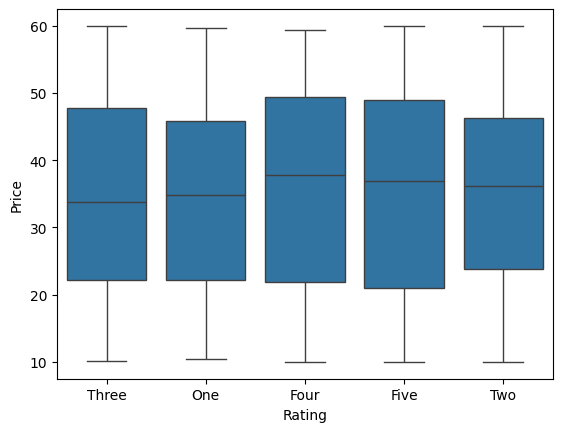

In [27]:
sns.boxplot(x='Rating', y= 'Price', data=df)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
plt.show()

<Axes: >

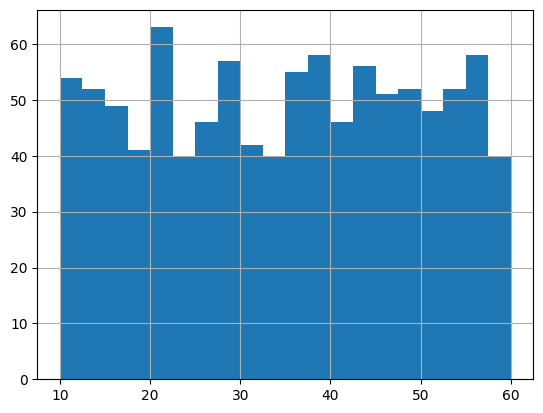

In [28]:
df["Price"].hist(bins=20)

In [10]:

prices=[]
ratings=[]
titles=[]
categories=[]
upcs=[]
availability_list=[]

import time 

for page in range(1,51):
    url=f"http://books.toscrape.com/catalogue/page-{page}.html" 
    response = requests.get(url) 
    soup= BeautifulSoup(response.text,"html.parser") 
    books= soup.find_all("article",class_= "product_pod") 
    print("page:", page,"books:", len(books))
    for book in books: 
        link= book.h3.a["href"]
        link= "http://books.toscrape.com/catalogue/" + link 
        
        
        try:
            book_page= requests.get(link, timeout=10)
            time.sleep(0)
            book_soup=BeautifulSoup(book_page.text,"html.parser")
            category=book_soup.find("ul", class_="breadcrumb").find_all("a")[2].text
            upc=book_soup.find("table").find_all("td")[0].text
            availability=book_soup.find("p",class_="instock availability").text.strip()
            title=book.h3.a["title"]
            price=book.find("p", class_="price_color").text
            rating= book.find("p",class_= "star-rating")["class"][1]
    
        
            categories.append(category)
            availability_list.append(availability)
            upcs.append(upc)
            titles.append(title) 
            prices.append (price)
            ratings. append(rating)     
    
        except Exception as e:
            print(e)
             
    


df=pd.DataFrame({"Title":titles, "Price":prices, "ratings":ratings, "categories":categories,"availability_list":availability_list, "upcs":upcs})

page: 1 books: 20
page: 2 books: 20
page: 3 books: 20
page: 4 books: 20
page: 5 books: 20
page: 6 books: 20
page: 7 books: 20
page: 8 books: 20
page: 9 books: 20
page: 10 books: 20
page: 11 books: 20
page: 12 books: 20
page: 13 books: 20
page: 14 books: 20
page: 15 books: 20
page: 16 books: 20
page: 17 books: 20
page: 18 books: 20
page: 19 books: 20
page: 20 books: 20
page: 21 books: 20
page: 22 books: 20
page: 23 books: 20
page: 24 books: 20
page: 25 books: 20
page: 26 books: 20
page: 27 books: 20
page: 28 books: 20
page: 29 books: 20
page: 30 books: 20
page: 31 books: 20
page: 32 books: 20
page: 33 books: 20
page: 34 books: 20
page: 35 books: 20
page: 36 books: 20
page: 37 books: 20
page: 38 books: 20
page: 39 books: 20
page: 40 books: 20
page: 41 books: 20
page: 42 books: 20
page: 43 books: 20
page: 44 books: 20
page: 45 books: 20
page: 46 books: 20
page: 47 books: 20
page: 48 books: 20
page: 49 books: 20
page: 50 books: 20


In [33]:
df.shape


(1000, 3)

In [ ]:
df.head()

In [54]:
print(len(ratings))
print(len(prices))
print(len(categories))
print(len(titles))
print(len(upcs))
print(len(availability_list))      

1000
1000
1000
1000
1000
1000


In [11]:
df.describe()

,Title,Price,ratings,categories,availability_list,upcs
count,1000,1000,1000,1000,1000,1000
unique,999,903,5,50,21,1000
top,The Star-Touched Queen,Â£37.34,One,Default,In stock (3 available),a897fe39b1053632
freq,2,3,226,152,196,1


In [12]:
df.isnull().sum()



Title                0
Price                0
ratings              0
categories           0
availability_list    0
upcs                 0
dtype: int64

In [57]:
df.drop_duplicates(inplace = True)
df

,Title,Price,ratings,categories,availability_list,upcs,available
0,A Light in the Attic,51.77,NaN,Poetry,In stock (22 available),a897fe39b1053632,22
1,Tipping the Velvet,53.74,NaN,Historical Fiction,In stock (20 available),90fa61229261140a,20
2,Soumission,50.10,NaN,Fiction,In stock (20 available),6957f44c3847a760,20
3,Sharp Objects,47.82,NaN,Mystery,In stock (20 available),e00eb4fd7b871a48,20
4,Sapiens: A Brief History of Humankind,54.23,NaN,History,In stock (20 available),4165285e1663650f,20
...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,NaN,Classics,In stock (1 available),cd2a2a70dd5d176d,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,NaN,Sequential Art,In stock (1 available),bfd5e1701c862ac3,1
997,A Spy's Devotion (The Regency Spies of London #1),16.97,NaN,Historical Fiction,In stock (1 available),19fec36a1dfb4c16,1
998,1st to Die (Women's Murder Club #1),53.98,NaN,Mystery,In stock (1 available),f684a82adc49f011,1


In [17]:
df.groupby("categories")["Price"].mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x0000024C3FC5AE90>>

In [13]:
df["Price"]=df["Price"].str.replace("Â£","")
df["Price"]=df["Price"].astype(float)

In [14]:
df["available"]= df["availability_list"].str.extract(r"(\d+)").astype(int)
df

,Title,Price,ratings,categories,availability_list,upcs,available
0,A Light in the Attic,51.77,Three,Poetry,In stock (22 available),a897fe39b1053632,22
1,Tipping the Velvet,53.74,One,Historical Fiction,In stock (20 available),90fa61229261140a,20
2,Soumission,50.10,One,Fiction,In stock (20 available),6957f44c3847a760,20
3,Sharp Objects,47.82,Four,Mystery,In stock (20 available),e00eb4fd7b871a48,20
4,Sapiens: A Brief History of Humankind,54.23,Five,History,In stock (20 available),4165285e1663650f,20
...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,One,Classics,In stock (1 available),cd2a2a70dd5d176d,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Four,Sequential Art,In stock (1 available),bfd5e1701c862ac3,1
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Five,Historical Fiction,In stock (1 available),19fec36a1dfb4c16,1
998,1st to Die (Women's Murder Club #1),53.98,One,Mystery,In stock (1 available),f684a82adc49f011,1


In [37]:
df.dtypes

Title                 object
Price                float64
ratings               object
categories            object
availability_list     object
upcs                  object
available              int64
dtype: object

In [15]:
rating_map={"One":1, "Two":2 , "Three":3, "Four":4, "Five":5}
df["ratings"]=df["ratings"].map(rating_map)

In [18]:
df["ratings"].unique()
df

,Title,Price,ratings,categories,availability_list,upcs,available
0,A Light in the Attic,51.77,Three,Poetry,In stock (22 available),a897fe39b1053632,22
1,Tipping the Velvet,53.74,One,Historical Fiction,In stock (20 available),90fa61229261140a,20
2,Soumission,50.10,One,Fiction,In stock (20 available),6957f44c3847a760,20
3,Sharp Objects,47.82,Four,Mystery,In stock (20 available),e00eb4fd7b871a48,20
4,Sapiens: A Brief History of Humankind,54.23,Five,History,In stock (20 available),4165285e1663650f,20
...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,One,Classics,In stock (1 available),cd2a2a70dd5d176d,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Four,Sequential Art,In stock (1 available),bfd5e1701c862ac3,1
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Five,Historical Fiction,In stock (1 available),19fec36a1dfb4c16,1
998,1st to Die (Women's Murder Club #1),53.98,One,Mystery,In stock (1 available),f684a82adc49f011,1


In [16]:
df.groupby("categories")["Price"].mean().sort_values(ascending= False).round(2)

categories
Suspense              58.33
Novels                54.81
Politics              53.61
Health                51.45
New Adult             46.38
Christian             42.50
Sports and Games      41.17
Self Help             40.62
Travel                39.79
Fantasy               39.59
Art                   38.52
Parenting             37.35
History               37.29
Autobiography         37.05
Womens Fiction        36.79
Cultural              36.58
Classics              36.55
Contemporary          36.20
Fiction               36.07
Poetry                35.97
Horror                35.95
Short Stories         35.88
Add a comment         35.80
Music                 35.64
Young Adult           35.45
Spirituality          35.10
Sequential Art        34.57
Default               34.39
Christian Fiction     34.38
Nonfiction            34.26
Psychology            34.22
Romance               33.93
Science Fiction       33.80
Biography             33.66
Historical Fiction    33.64
Philosoph

In [27]:
df.groupby("categories")["ratings"].count().sort_values(ascending=False)

categories
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Womens Fiction         17
Horror                 17
Science Fiction        16
Science                14
Music                  13
Business               12
Philosophy             11
Thriller               11
Travel                 11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Christian Fiction       6
Spirituality            6
New Adult               6
Sports and Games        5
Biography               5
Self Help               5
Health                  4
Contemporary            3
Politics                3
C

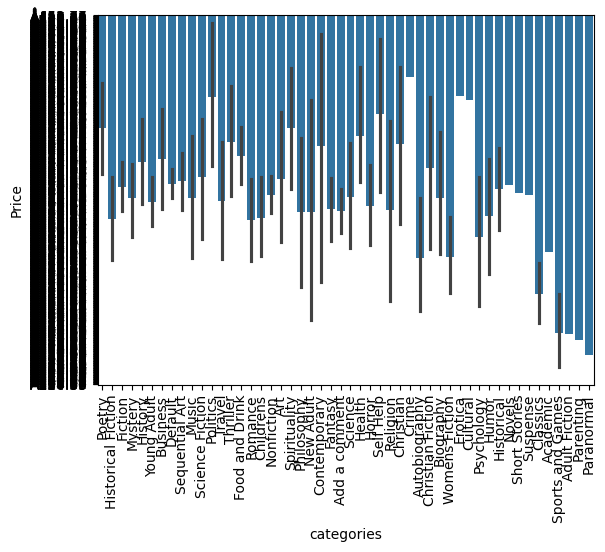

In [11]:
sns.barplot(x="categories",y="Price",data=df)
plt.xticks(rotation=90)
plt.show()

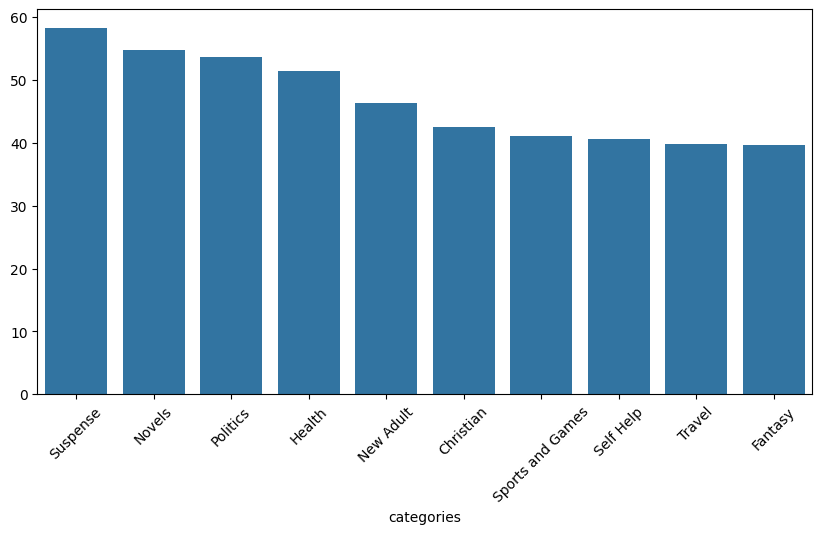

In [15]:
avg_price=df.groupy("categories")["Price"].mean().sort_values(ascending=False)
top10= avg_price.head(10)
plt.figure(figsize=(10,5))
sns.barplot (x=top10.index, y=top10.values)
plt.xticks(rotation=45)
plt.show()

In [ ]:
avg_price=df.groupby("categories")["Price"].mean().sort_values(ascending=False)
top20= avg_price.head(20)
plt.figure(figsize=(12,20))
sns.barplot(x=top20.index , y= top20.values )
plt.xticks(rotation=45)
plt.show()

In [33]:
df.groupby("categories")["Price"].median().sort_values(ascending =False)

categories
Suspense              58.330
Novels                54.810
Politics              52.650
Health                51.345
Christian             47.720
Self Help             46.350
Sports and Games      44.840
New Adult             44.180
Womens Fiction        43.580
Fantasy               43.580
Art                   42.080
History               41.290
Autobiography         40.850
Fiction               39.720
Biography             39.550
Travel                38.950
Poetry                38.770
Parenting             37.350
Horror                36.970
Young Adult           36.610
Cultural              36.580
Sequential Art        36.520
Add a comment         36.170
Default               36.025
Short Stories         35.880
Science Fiction       35.315
Music                 35.020
Spirituality          35.020
Classics              35.010
Romance               34.530
Christian Fiction     34.220
Business              33.630
Nonfiction            32.150
Food and Drink        31.830
Con

In [35]:
df.groupby("categories")["Price"].mean().sort_values(ascending=False)

categories
Suspense              58.330000
Novels                54.810000
Politics              53.613333
Health                51.452500
New Adult             46.383333
Christian             42.496667
Sports and Games      41.166000
Self Help             40.620000
Travel                39.794545
Fantasy               39.593958
Art                   38.520000
Parenting             37.350000
History               37.295000
Autobiography         37.053333
Womens Fiction        36.791176
Cultural              36.580000
Classics              36.545263
Contemporary          36.200000
Fiction               36.066615
Poetry                35.974211
Horror                35.949412
Short Stories         35.880000
Add a comment         35.796418
Music                 35.636923
Young Adult           35.449074
Spirituality          35.098333
Sequential Art        34.572267
Default               34.392697
Christian Fiction     34.385000
Nonfiction            34.260182
Psychology            34.2185

In [ ]:
df["categories"].value_counts().sort_values(ascending=False)

### Categories with higher average  prices have very low sample sizes. which likely inflates their mean. Categories with larger counts show more stable and representative.

In [42]:
df.groupby("categories")["Price"].max().sort_values(ascending=False)

categories
Romance               59.99
Fiction               59.98
Psychology            59.95
Food and Drink        59.92
Nonfiction            59.90
Thriller              59.71
History               59.64
Mystery               59.48
Add a comment         59.15
Autobiography         59.04
Default               58.87
Fantasy               58.75
Classics              58.63
New Adult             58.35
Suspense              58.33
Young Adult           58.14
Philosophy            58.11
Childrens             58.08
Horror                57.86
Sequential Art        57.62
Religion              57.49
Science               57.36
Womens Fiction        57.36
Poetry                57.31
Music                 57.25
Travel                56.88
Politics              56.86
Spirituality          55.65
Historical Fiction    55.55
Humor                 55.50
Science Fiction       54.86
Novels                54.81
Health                54.07
Christian             54.00
Contemporary          52.79
Self Help

### Maximum price is not a good differentiator between categories but average price reveals distribution differences.

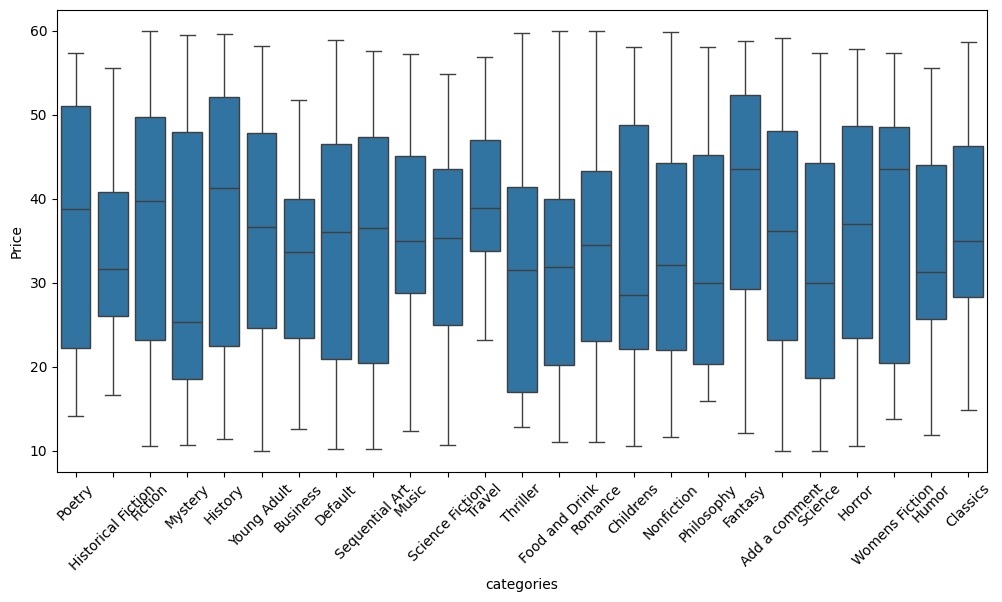

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x="categories", y="Price", data = df_clean)
plt.xticks(rotation=45)
plt.show()

In [45]:
df.groupby("categories")["Price"].agg(["median","count"])

,median,count
categories,,
Academic,13.120,1
Adult Fiction,15.360,1
Art,42.080,8
Autobiography,40.850,9
Biography,39.550,5
Business,33.630,12
Childrens,28.540,29
Christian,47.720,3
Christian Fiction,34.220,6


In [16]:
 df= df[df["categories"] != "Add a comment"]

### Variaton in median prices is partly influenced by sample size . but primarily reflects differences in underlying price distributions accross categories.

In [20]:
valid= df["categories"].value_counts()
valid= valid[valid >= 10].index 
df_clean= df[df["categories"].isin(valid)]

In [40]:
df["ratings"].unique()

array([3, 1, 4, 5, 2])

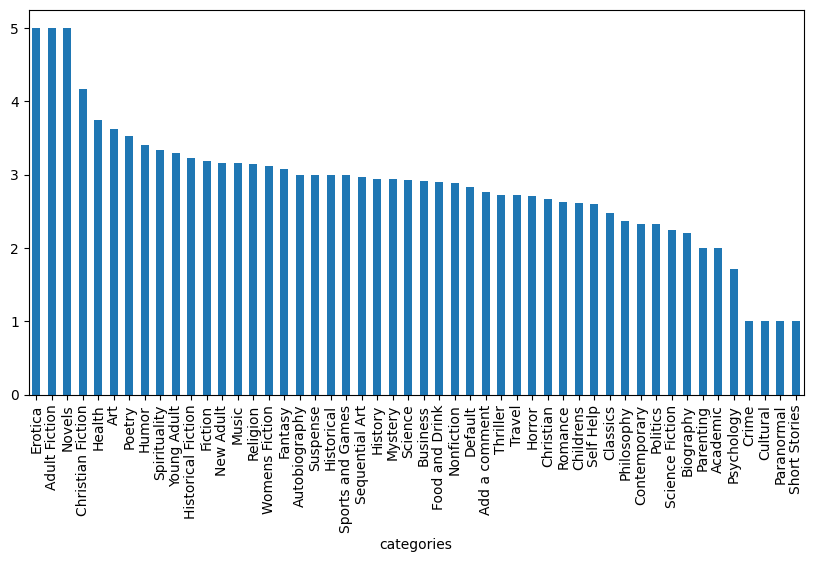

In [51]:
top=df.groupby("categories")["ratings"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
top.plot(kind="bar")
plt.xticks(rotation=90)
plt.show()

In [39]:
df["ratings"].value_counts()

ratings
1    226
3    203
5    196
2    196
4    179
Name: count, dtype: int64

In [54]:
df.groupby("categories")["ratings"].median().sort_values(ascending=False)

categories
Erotica               5.0
Adult Fiction         5.0
Novels                5.0
Christian Fiction     4.5
Health                4.0
Art                   4.0
Young Adult           4.0
Poetry                4.0
Womens Fiction        4.0
Science               3.5
Humor                 3.5
Spirituality          3.5
Fantasy               3.0
Add a comment         3.0
Childrens             3.0
Default               3.0
Fiction               3.0
Business              3.0
Travel                3.0
Suspense              3.0
Sports and Games      3.0
Nonfiction            3.0
Sequential Art        3.0
Romance               3.0
Self Help             3.0
Religion              3.0
Music                 3.0
Horror                3.0
New Adult             3.0
Mystery               3.0
Historical Fiction    3.0
History               3.0
Historical            3.0
Food and Drink        3.0
Thriller              2.0
Science Fiction       2.0
Parenting             2.0
Classics              2.0
B

In [30]:
df.groupby("ratings")["Price"].mean().sort_values(ascending=False)

ratings
4    36.166566
5    35.326383
3    34.864785
2    34.497322
1    34.424381
Name: Price, dtype: float64

In [35]:
result= df.groupby("categories")["ratings"].agg(["mean","count"]).sort_values(by=["count"], ascending=[True])
result= result[result["count"]>10]
result

,mean,count
categories,,
Philosophy,2.363636,11
Travel,2.727273,11
Thriller,2.727273,11
Business,2.916667,12
Music,3.153846,13
Science,2.928571,14
Science Fiction,2.250000,16
Womens Fiction,3.117647,17
Horror,2.705882,17


In [36]:
df["ratings"].value_counts()

ratings
1    210
5    188
3    186
2    183
4    166
Name: count, dtype: int64

In [37]:
df[df["ratings"] >= 4].groupby("categories").size().sort_values(ascending = False)

categories
Default               52
Nonfiction            38
Young Adult           30
Sequential Art        29
Fiction               27
Fantasy               21
Mystery               12
Historical Fiction    12
Poetry                12
Food and Drink        10
Romance                9
Womens Fiction         9
Science                7
Childrens              7
History                6
Art                    5
Science Fiction        5
Music                  5
Humor                  5
Horror                 5
Christian Fiction      5
Autobiography          4
Business               4
Classics               4
Thriller               4
Philosophy             4
Religion               3
Spirituality           3
Travel                 3
New Adult              2
Sports and Games       2
Health                 2
Christian              1
Adult Fiction          1
Historical             1
Contemporary           1
Erotica                1
Politics               1
Novels                 1
Self Help     

### Although average ratings across categories are moderate (2-3) deeper analysis high- rated books (>=4) are relatively rare ,indicating a skewed rating distribution. certain categories like default, Nonfiction, and young adult still contain the highest number of well rated books.   

In [25]:
df[(df["Price"]>50) & (df["ratings"]>4)]

,Title,Price,ratings,categories,availability_list,upcs,available
4,Sapiens: A Brief History of Humankind,54.23,5,History,In stock (20 available),4165285e1663650f,20
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,Sequential Art,In stock (19 available),3b1c02bac2a429e6,19
46,"We Love You, Charlie Freeman",50.27,5,Fiction,In stock (16 available),8d455c7539795d2a,16
100,Immunity: How Elie Metchnikoff Changed the Cou...,57.36,5,Science,In stock (16 available),e4f74c16de34d440,16
122,"A Piece of Sky, a Grain of Rice: A Memoir in F...",56.76,5,Default,In stock (16 available),8a380641491d43ed,16
124,A Flight of Arrows (The Pathfinders #2),55.53,5,Historical Fiction,In stock (16 available),3a6fb983e2554023,16
127,(Un)Qualified: How God Uses Broken People to D...,54.00,5,Christian,In stock (16 available),e4ac92d89b946781,16
142,The Regional Office Is Under Attack!,51.36,5,Fiction,In stock (15 available),0651062381f0636a,15
193,Finders Keepers (Bill Hodges Trilogy #2),53.53,5,Fiction,In stock (15 available),edb3097e71330040,15
213,Amatus,50.54,5,Default,In stock (15 available),ffd54178acc9a6a5,15


In [27]:
df[(df["Price"]<20) & (df["ratings"]<2)]

,Title,Price,ratings,categories,availability_list,upcs,available
20,In Her Wake,12.84,1,Thriller,In stock (19 available),23356462d1320d61,19
37,"In a Dark, Dark Wood",19.63,1,Mystery,In stock (18 available),19ed25f4641d5efd,18
51,Tsubasa: WoRLD CHRoNiCLE 2 (Tsubasa WoRLD CHRo...,16.28,1,Sequential Art,In stock (16 available),09555be379ad9253,16
55,The Torch Is Passed: A Harding Family Story,19.09,1,Add a comment,In stock (16 available),4eed62cf5f8d8edf,16
71,The Age of Genius: The Seventeenth Century and...,19.73,1,History,In stock (16 available),a3d2a4250807f1e9,16
82,"Pop Gun War, Volume 1: Gift",18.97,1,Sequential Art,In stock (16 available),e80f8e518b300dfe,16
123,A Murder in Time,16.64,1,Mystery,In stock (16 available),f733e8c19d40ec2e,16
144,The Project,10.65,1,Science Fiction,In stock (15 available),790ef197c8f236f5,15
152,The Long Shadow of Small Ghosts: Murder and Me...,10.97,1,Crime,In stock (15 available),abeafe151a587d3b,15
157,The Genius of Birds,17.24,1,Nonfiction,In stock (15 available),42d0d7c92b75fc1c,15


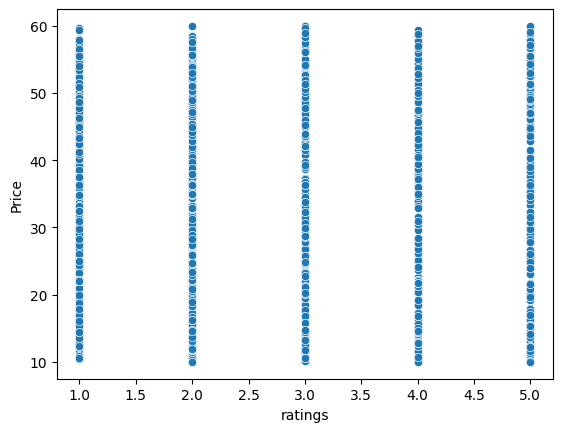

In [28]:
sns.scatterplot(x= "ratings", y= "Price", data=df)
plt.show()


<Axes: xlabel='ratings', ylabel='Price'>

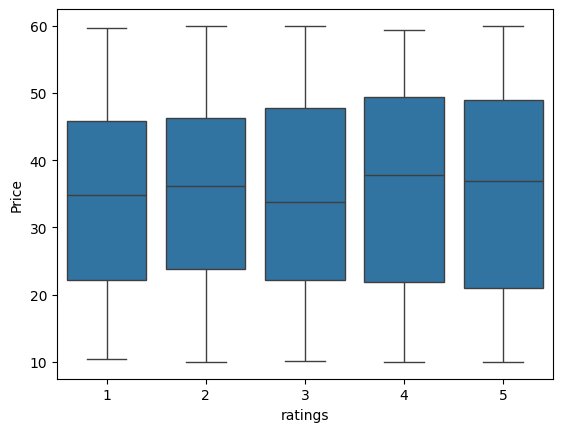

In [29]:

sns.boxplot(x="ratings", y="Price", data=df)

### there is no significant relationship between book price and rating. Books accross all rating levels exhibit a wide price range, indicating that price doesnot determine percieved quality.